# Figure5_2

In [1]:
from pathlib import Path

FIGURE_OUTPUT_DIR = Path("results/Figure5")
FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
import os

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from functions.load_data import loadTrialsM
from functions.utils import first_trial_accuracy
from functions.decoding import load_feature_mat, pca_standardize, fit_logistic
from functions.plotting import set_paper_theme

set_paper_theme(tick_width=0.3)


## Panel C — Cross-task model performance

### Classification

In [3]:

task_names = ["animate_vs_inanimate","natural_vs_artificial","mammal_vs_reptile","electronics_vs_tools","human_vs_monkey","monkey_vs_mammal",
              "electronics_vs_tools_THINGS","outdoor_vs_indoor","big_vs_small","big_vs_small_Konkle","fire related_vs_water related","eastern_vs_western"]
models = ["alexnet","vgg16","resnet50","vit_b_32","clip","siglip2"]


In [4]:

acc_task = []
for task in task_names:
    acc_models = []
    for model_name in models:
        feature_main = f"data_model/smalltask_features/{task}_{model_name}.mat"
        feature_gen = f"data_model/smalltask_features/{task}_gen_{model_name}.mat"
        if not os.path.exists(feature_main):
            acc_models.append(np.nan)
            continue

        x_main, category_main, _ = load_feature_mat(feature_main)
        x_gen, category_gen, _ = load_feature_mat(feature_gen)

        # shipped PCA-20 features already carry the PCA step
        x_main, x_gen = pca_standardize(x_main, x_gen)

        pred = fit_logistic(x_main, category_main).predict(x_gen)
        accu = np.sum(pred==category_gen)/x_gen.shape[0]
        acc_models.append(accu)
        print(f"{task} {model_name}  {accu:.3}")

    acc_task.append(acc_models)

accu = np.array(acc_task)
accu.shape


animate_vs_inanimate alexnet  0.917
animate_vs_inanimate vgg16  0.927
animate_vs_inanimate resnet50  0.969
animate_vs_inanimate vit_b_32  0.854
animate_vs_inanimate clip  0.979
animate_vs_inanimate siglip2  0.99
natural_vs_artificial alexnet  0.975
natural_vs_artificial vgg16  0.95
natural_vs_artificial resnet50  1.0
natural_vs_artificial vit_b_32  0.9
natural_vs_artificial clip  1.0
natural_vs_artificial siglip2  1.0
mammal_vs_reptile alexnet  0.95
mammal_vs_reptile vgg16  1.0
mammal_vs_reptile resnet50  1.0
mammal_vs_reptile vit_b_32  0.95
mammal_vs_reptile clip  1.0
mammal_vs_reptile siglip2  1.0
electronics_vs_tools alexnet  0.743
electronics_vs_tools vgg16  0.829
electronics_vs_tools resnet50  0.929
electronics_vs_tools vit_b_32  0.7
electronics_vs_tools clip  0.929
electronics_vs_tools siglip2  0.971
human_vs_monkey alexnet  1.0
human_vs_monkey vgg16  1.0
human_vs_monkey resnet50  1.0
human_vs_monkey vit_b_32  1.0
human_vs_monkey clip  1.0
human_vs_monkey siglip2  1.0
monkey_vs_m

(12, 6)

In [5]:

task_names_label = ["Animate vs. Inanimate","Natural vs. Artificial","Mammal vs. Non-mammal","Tools vs. Electronics","Human vs. Monkey","Monkey vs. Mammal",
            "Tools vs. Electronics(THINGS)","Outdoor vs. Indoor","Big vs. Small","Big vs. Small(Konkle)","Fire related vs. Water related","Eastern vs. Western"]
model_names_label = ["AlexNet","VGG16","ResNet50","Vit-B/32","CLIP","SigLIP2"]

cmap = mpl.colormaps['tab10'].colors
colors = [cmap[0],cmap[1],cmap[2],cmap[3],cmap[4],cmap[5]]


In [6]:

CR = []
SE = []
for task in [f"{name}_gen" for name in task_names]:
    cr = []
    for monkey in ["Elsa","Judy","Olaf"]:
        trials,_ = loadTrialsM(task,monkey)
        trials_gen = [trial for trial in trials if trial["trial_type"]=="gen"]
        _,_,res = first_trial_accuracy(trials_gen)
        cr.append(res)

    print(f"{np.mean(np.mean(cr,axis=0)):.4} {task}")

    cr_avg = np.mean(cr,axis=0)
    CR.append(np.mean(cr_avg))
    SE.append(np.sqrt(np.mean(cr_avg)*(1-np.mean(cr_avg))/len(cr_avg)))


0.7951 animate_vs_inanimate_gen
0.7792 natural_vs_artificial_gen
0.8611 mammal_vs_reptile_gen
0.6667 electronics_vs_tools_gen
0.7833 human_vs_monkey_gen
0.8 monkey_vs_mammal_gen
0.6667 electronics_vs_tools_THINGS_gen
0.7722 outdoor_vs_indoor_gen
0.8 big_vs_small_gen
0.7533 big_vs_small_Konkle_gen
0.5688 fire related_vs_water related_gen
0.4767 eastern_vs_western_gen


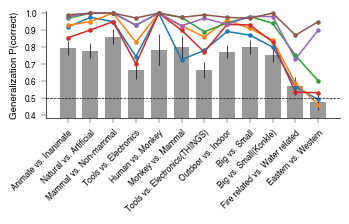

In [7]:
fig,ax = plt.subplots(layout="none")
fig.set(figheight=80/75,figwidth=220/75)
# no layout engine: constrained_layout breaks with long rotated tick labels on this small figure.
# Fill the whole figure with the axes so the panel keeps its physical size;
# labels hanging outside are captured by bbox_inches="tight" at savefig.
fig.subplots_adjust(left=0,right=1,top=1,bottom=0)

ax.bar(range(len(task_names_label)),CR,yerr=SE,width=0.7,color="#999999",error_kw={"linewidth":0.5},zorder=0)

for i,model in enumerate(model_names_label):
    res = accu[:,i]
    ax.plot(range(len(task_names_label)),res,color=colors[i],linewidth=1.1,label=model_names_label[i],zorder=1)
    ax.scatter(range(len(task_names_label)),res,color=colors[i],linewidth=1,s=5,zorder=2)

ax.axhline(0.5,color="black",linewidth=0.5,linestyle="--")
# anchor the rotated labels' upper end at their tick
ax.set_xticks(range(len(task_names_label)),task_names_label,
              rotation=45,ha="right",va="top",rotation_mode="anchor")
ax.set_yticks([0.4,0.5,0.6,0.7,0.8,0.9,1.0],[0.4,0.5,0.6,0.7,0.8,0.9,1.0],rotation=0)
ax.set_ylabel("Generalization P(correct)")
ax.set_ylim([0.38,1.01])

# Save with constrained layout explicitly off: savefig(bbox_inches="tight")
# would otherwise re-attach the rcParam layout engine, which then squeezes
# the axes when plt.show() renders the inline preview below.
with plt.rc_context({"figure.constrained_layout.use": False}):
    plt.savefig(FIGURE_OUTPUT_DIR / "dnn_generalization_by_task.pdf", bbox_inches="tight")
plt.show()


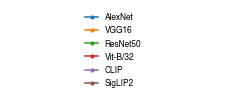

In [8]:
# standalone legend for the model lines, saved as a separate PDF
fig,ax = plt.subplots(layout="none")
fig.set(figheight=30/75,figwidth=200/75)
for i,model in enumerate(model_names_label):
    ax.plot([],[],color=colors[i],linewidth=1.1,marker="o",markersize=2,label=model_names_label[i])
ax.legend(frameon=False,loc="center",ncols=1,handlelength=1.5,columnspacing=1)
ax.axis("off")
# Save with constrained layout explicitly off: savefig(bbox_inches="tight")
# would otherwise re-attach the rcParam layout engine, which then squeezes
# the axes when plt.show() renders the inline preview below.
with plt.rc_context({"figure.constrained_layout.use": False}):
    plt.savefig(FIGURE_OUTPUT_DIR / "dnn_model_legend.pdf", bbox_inches="tight")
plt.show()
